# Model 1 — robust temperature-only baseline

Final baseline model:

$$
y_i=\log(PR_i)
$$

$$
y_i \sim StudentT(\nu,\mu_i,\sigma)
$$

$$
\mu_i=\alpha+\beta_T x_{T,i}
$$

where:

$$
x_T=\frac{T_m-T_{min}}{T_{max}-T_{min}}
$$

$T_{min}$ and $T_{max}$ are computed from the filtered modelling dataset, so $x_T$ is always in the range $[0,1]$. With this normalization, $\alpha$ is the expected $\log(PR)$ at the minimum observed module temperature, while $\beta_T$ is the change in $\log(PR)$ between the minimum and maximum observed module temperature.

The model uses a Student-t likelihood to make inference robust to remaining outliers. It captures the temperature relationship only and does not include wind or day-level effects.

In [27]:
from pathlib import Path
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
from cmdstanpy import CmdStanModel

RANDOM_SEED = 42
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

## 1. Load moderate dataset

In [28]:
DATA_PATH = "onemin-Ground-2016/2016/ground_model_data_moderate.csv"
df = pd.read_csv(DATA_PATH)

print("Using clean data:", DATA_PATH)

STAN_MODEL_PATH = Path("model_1_temperature_studentt.stan")
STAN_PRIOR_PATH = Path("model_1_temperature_studentt_prior_predictive.stan")

print("Using data:", DATA_PATH)
print("Raw shape:", df.shape)
print(df.columns.tolist())

required = ["logPR", "PR", "T_module_C"]
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=required).copy()

temp_min = df["T_module_C"].min()
temp_max = df["T_module_C"].max()
temp_range = temp_max - temp_min
df["x_T"] = (df["T_module_C"] - temp_min) / temp_range

if "day_id" in df.columns:
    df["day_id"] = pd.factorize(df["day_id"])[0] + 1

print("Model shape:", df.shape)
print(f"Temperature range: {temp_min:.2f} ... {temp_max:.2f} degC")
df[["logPR", "PR", "x_T", "T_module_C"]].head()

Using clean data: onemin-Ground-2016/2016/ground_model_data_moderate.csv
Using data: onemin-Ground-2016/2016/ground_model_data_moderate.csv
Raw shape: (1486, 15)
['timestamp', 'day', 'day_id', 'month', 'hour', 'logPR', 'PR', 'x_T', 'z_wind', 'T_module_C', 'wind_ms', 'G_POA_Wm2', 'P_DC_kW', 'expected_P_DC_kW', 'power_ratio']
Model shape: (1486, 15)
Temperature range: 21.78 ... 65.87 degC


,logPR,PR,x_T,T_module_C
0,-0.128713,0.879226,0.826491,58.22
1,-0.141172,0.868340,0.848265,59.18
2,-0.134383,0.874255,0.875028,60.36
3,-0.129893,0.878190,0.834883,58.59
4,-0.138943,0.870278,0.885008,60.80


## 2. Prepare Stan data

In [29]:
y = df["logPR"].to_numpy()
x_T = df["x_T"].to_numpy()
N = len(df)

stan_data = {"N": N, "y": y, "x_T": x_T, "temp_range": temp_range}
prior_data = {"N": N, "x_T": x_T, "temp_range": temp_range}

print("N =", N)
print("x_T range:", x_T.min(), x_T.max())
print("Temperature range [degC]:", temp_range)
print("PR range:", df["PR"].min(), df["PR"].max())

N = 1486
x_T range: 0.0 1.0
Temperature range [degC]: 44.09
PR range: 0.513241766948783 1.11252867182318


## 3. EDA

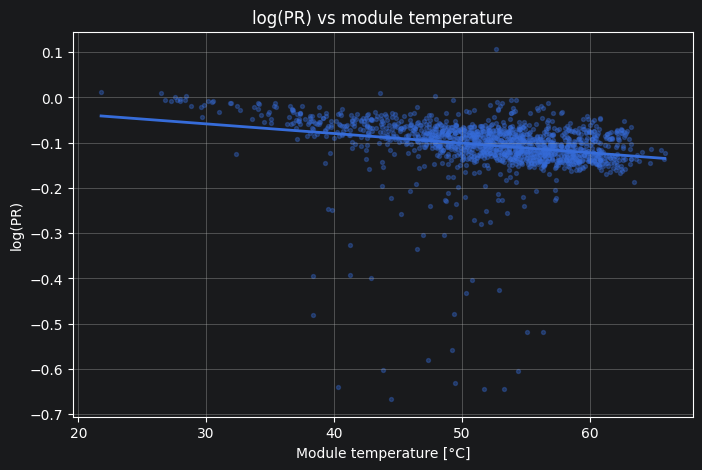

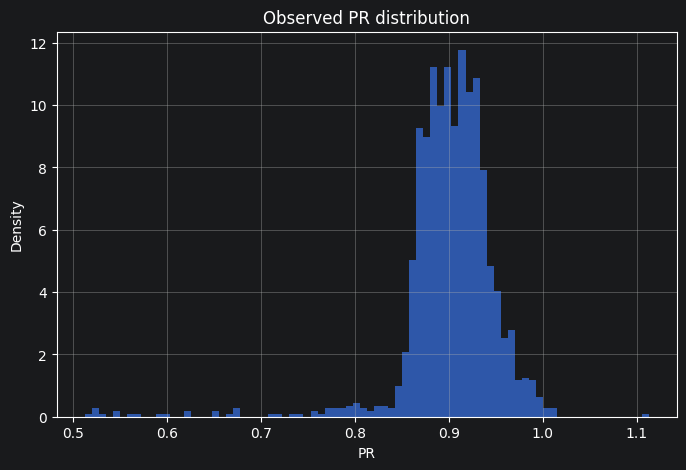

In [30]:
plt.figure()
plt.scatter(df["T_module_C"], df["logPR"], s=8, alpha=0.35)
p = np.polyfit(df["T_module_C"], df["logPR"], 1)
xx = np.linspace(df["T_module_C"].min(), df["T_module_C"].max(), 200)
plt.plot(xx, np.polyval(p, xx), linewidth=2)
plt.xlabel("Module temperature [°C]")
plt.ylabel("log(PR)")
plt.title("log(PR) vs module temperature")
plt.show()

plt.figure()
plt.hist(df["PR"], bins=80, density=True, alpha=0.75)
plt.xlabel("PR")
plt.ylabel("Density")
plt.title("Observed PR distribution")
plt.show()

## 4. Prior predictive check

Prior predictive checks assess whether the assumed priors generate plausible PR values before conditioning on the data. The summaries include $\beta_T$ on the normalized temperature scale and the corresponding $+10^\circ C$ effect for physical interpretation.

In [31]:

prior_model = CmdStanModel(stan_file=str(STAN_PRIOR_PATH))
prior_fit = prior_model.sample(
    data=prior_data,
    chains=4,
    iter_warmup=500,
    iter_sampling=500,
    seed=RANDOM_SEED,
)

alpha_prior = prior_fit.stan_variable("alpha")
beta_T_prior = prior_fit.stan_variable("beta_T")
beta_T_per_10C_prior = prior_fit.stan_variable("beta_T_per_10C")
sigma_prior = prior_fit.stan_variable("sigma")
nu_prior = prior_fit.stan_variable("nu")
PR_prior = prior_fit.stan_variable("PR_prior")

print("Prior alpha:", np.percentile(alpha_prior, [5, 50, 95]))
print("Prior beta_T (0 to 1 temperature scale):", np.percentile(beta_T_prior, [5, 50, 95]))
print("Prior beta_T per +10 degC:", np.percentile(beta_T_per_10C_prior, [5, 50, 95]))
print("Prior sigma:", np.percentile(sigma_prior, [5, 50, 95]))
print("Prior nu:", np.percentile(nu_prior, [5, 50, 95]))
print("Prior predictive PR:", np.percentile(PR_prior.flatten(), [1, 5, 50, 95, 99]))

23:30:52 - cmdstanpy - INFO - compiling stan file /Users/jwiater/Documents/private/da_project/model_1_temperature_studentt_prior_predictive.stan to exe file /Users/jwiater/Documents/private/da_project/model_1_temperature_studentt_prior_predictive
23:30:56 - cmdstanpy - INFO - compiled model executable: /Users/jwiater/Documents/private/da_project/model_1_temperature_studentt_prior_predictive
23:30:57 - cmdstanpy - INFO - CmdStan start processing
chain 2:   0%|          | 0/1000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/1000 [00:00<?, ?it/s, (Warmup)]


chain 2:  50%|█████     | 500/1000 [00:00<00:00, 5930.49it/s, (Sampling)]

chain 3:  50%|█████     | 500/1000 [00:00<00:00, 5761.77it/s, (Sampling)]


chain 2:  60%|██████    | 600/1000 [00:00<00:00, 3052.77it/s, (Sampling)]

chain 3:  60%|██████    | 600/1000 [00:00<00:00, 3024.50it/s, (Sampling)]


chain 1: 100%|██████████| 1000/1000 [00:00<00:00, 1380.84it/s, (Sampling)][A


chain 2: 100%|██████████| 1000/1000 [00:00<00:0


23:30:58 - cmdstanpy - INFO - CmdStan done processing.



Prior alpha: [-0.7950519  -0.28809783  0.22142786]
Prior beta_T (0 to 1 temperature scale): [-3.59366623 -0.03240677  3.62100704]
Prior beta_T per +10 degC: [-0.81507512 -0.00735014  0.82127627]
Prior sigma: [0.00471423 0.03373077 0.09483147]
Prior nu: [ 6.72167293 17.3750925  31.66834555]
Prior predictive PR: [1.60246336e-02 5.65386798e-02 7.24613860e-01 1.03433394e+01
 3.49330834e+01]


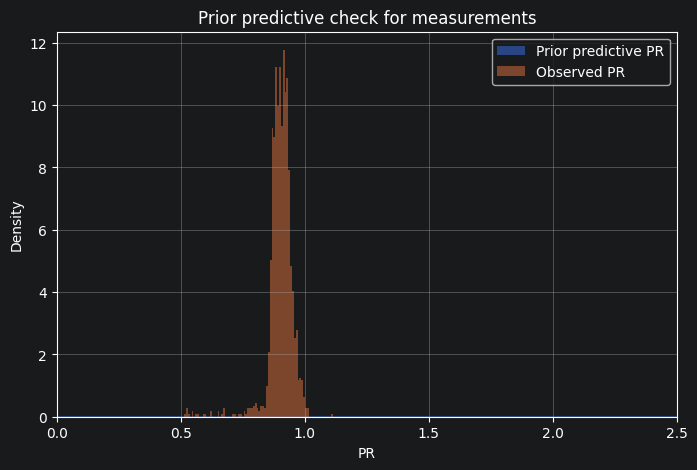

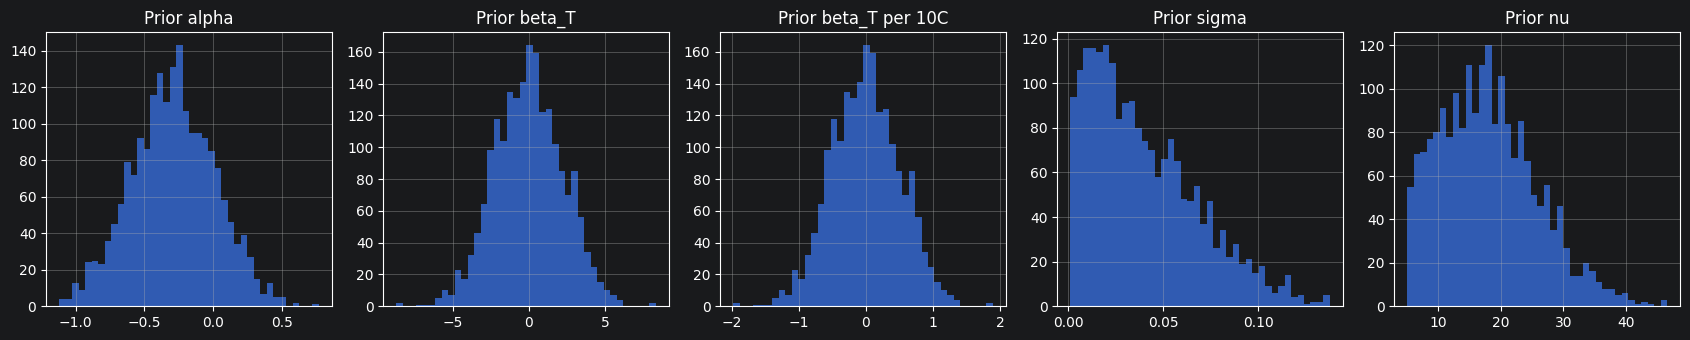

In [32]:
plt.figure()
plt.hist(PR_prior.flatten(), bins=100, density=True, alpha=0.55, label="Prior predictive PR")
plt.hist(df["PR"], bins=80, density=True, alpha=0.55, label="Observed PR")
plt.xlim(0, 2.5)
plt.xlabel("PR")
plt.ylabel("Density")
plt.title("Prior predictive check for measurements")
plt.xlim([0, 2.5])
plt.legend()
plt.show()

fig, axes = plt.subplots(1, 5, figsize=(17, 3.5))
for ax, (name, samples) in zip(
    axes,
    [
        ("alpha", alpha_prior),
        ("beta_T", beta_T_prior),
        ("beta_T per 10C", beta_T_per_10C_prior),
        ("sigma", sigma_prior),
        ("nu", nu_prior),
    ]
):
    ax.hist(samples, bins=40, alpha=0.8)
    ax.set_title(f"Prior {name}")
    ax.grid(True)
plt.tight_layout()
plt.show()

## 5. Fit Model 1

In [33]:

model = CmdStanModel(stan_file=str(STAN_MODEL_PATH))
fit = model.sample(
    data=stan_data,
    chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    seed=RANDOM_SEED,
    adapt_delta=0.95,
    max_treedepth=12,
)

23:30:59 - cmdstanpy - INFO - CmdStan start processing
chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]


chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   5%|▌         | 100/2000 [00:00<00:02, 792.04it/s, (Warmup)]


chain 1:   5%|▌         | 100/2000 [00:00<00:08, 226.46it/s, (Warmup)]


chain 2:  10%|█         | 200/2000 [00:00<00:05, 302.72it/s, (Warmup)]


chain 2:  15%|█▌        | 300/2000 [00:00<00:04, 377.17it/s, (Warmup)]

chain 3:  10%|█         | 200/2000 [00:00<00:08, 206.28it/s, (Warmup)]


chain 2:  20%|██        | 400/2000 [00:01<00:03, 430.54it/s, (Warmup)]

chain 3:  15%|█▌        | 300/2000 [00:01<00:06, 254.83it/s, (Warmup)]


chain 2:  25%|██▌       | 500/2000 [00:01<00:03, 424.29it/s, (Warmup)]

chain 2:  30%|███       | 600/2000 [00:01<00:02, 490.86it/s, (Warmup)]


chain 2:  35%|███▌      | 700/2000 [00:01<00:02, 532.73it/s, (Warmup)]

chain 3:  25%|██▌       | 500/2000 


23:31:05 - cmdstanpy - INFO - CmdStan done processing.


## 6. Diagnostics

In [34]:
print(fit.diagnose())
summary = fit.summary()
display(summary.loc[["alpha", "beta_T", "beta_T_per_10C", "sigma", "nu"]])

draws_pd = fit.draws_pd()
div_cols = [c for c in draws_pd.columns if c.endswith("__") and "divergent" in c]
n_div = int(draws_pd[div_cols[0]].sum()) if div_cols else 0
print("Number of divergences:", n_div)

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
alpha,-0.005112,0.000065,0.003393,0.003435,-0.010662,-0.005135,0.000396,2694.28,2159.17,234.939,1.00085
beta_T,-0.135333,0.000093,0.004848,0.004916,-0.143226,-0.135304,-0.127555,2716.93,2373.30,236.914,1.00036
beta_T_per_10C,-0.030695,0.000021,0.001100,0.001115,-0.032485,-0.030688,-0.028931,2716.93,2373.30,236.914,1.00036
sigma,0.027061,0.000016,0.000653,0.000640,0.026029,0.027030,0.028204,1718.54,1508.54,149.856,1.00099
nu,5.031660,0.000632,0.031620,0.022113,5.001670,5.021690,5.096970,1711.24,1523.77,149.219,1.00208


Number of divergences: 0


## 7. Posterior analysis

In [35]:
alpha = fit.stan_variable("alpha")
beta_T = fit.stan_variable("beta_T")
beta_T_per_10C = fit.stan_variable("beta_T_per_10C")
sigma = fit.stan_variable("sigma")
nu = fit.stan_variable("nu")
mu = fit.stan_variable("mu")

effect_full_range_pct = 100 * (np.exp(beta_T) - 1)
effect_10C_pct = 100 * (np.exp(beta_T_per_10C) - 1)
effect_1C_pct = 100 * (np.exp(beta_T_per_10C / 10) - 1)

print(f"P(beta_T < 0 | data) = {np.mean(beta_T < 0):.4f}")
print("beta_T percentiles (0 to 1 temperature scale):", np.percentile(beta_T, [5, 50, 95]))
print("beta_T per +10 degC percentiles:", np.percentile(beta_T_per_10C, [5, 50, 95]))
print("Effect across observed temperature range [%]:", np.percentile(effect_full_range_pct, [5, 50, 95]))
print("Effect per +10°C [%]:", np.percentile(effect_10C_pct, [5, 50, 95]))
print("Effect per +1°C [%]:", np.percentile(effect_1C_pct, [5, 50, 95]))
print("sigma percentiles:", np.percentile(sigma, [5, 50, 95]))
print("nu percentiles:", np.percentile(nu, [5, 50, 95]))

P(beta_T < 0 | data) = 1.0000
beta_T percentiles (0 to 1 temperature scale): [-0.14322613 -0.13530375 -0.1275548 ]
beta_T per +10 degC percentiles: [-0.03248495 -0.03068808 -0.02893055]
Effect across observed temperature range [%]: [-13.34419115 -12.65494436 -11.97548251]
Effect per +10°C [%]: [-3.19629792 -3.02219829 -2.85160704]
Effect per +1°C [%]: [-0.32432241 -0.30641042 -0.28888744]
sigma percentiles: [0.02602897 0.02703041 0.02820438]
nu percentiles: [5.00166671 5.0216925  5.09696564]


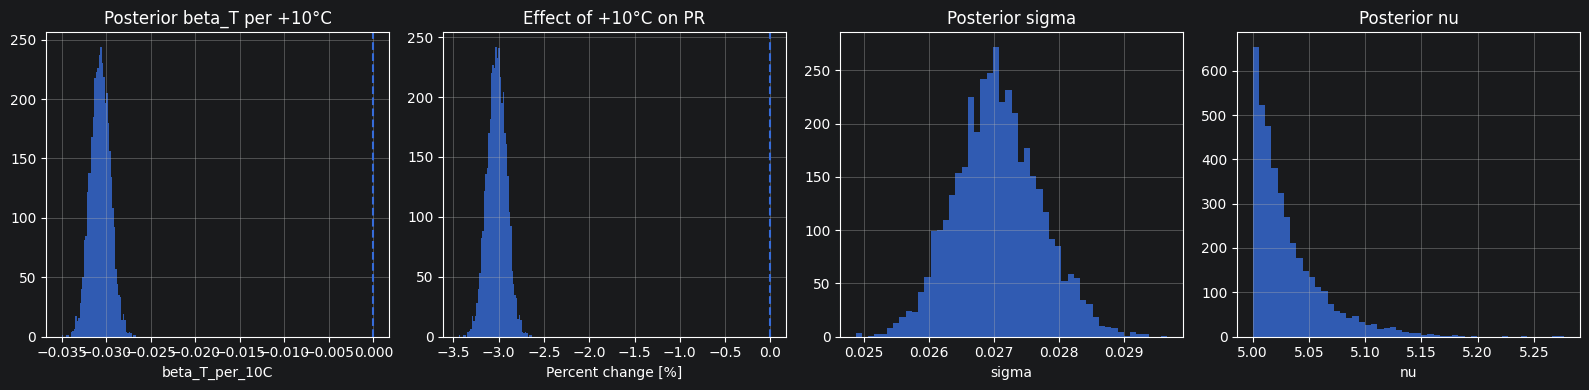

In [36]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
plots = [
    ("Posterior beta_T per +10°C", beta_T_per_10C, "beta_T_per_10C", True),
    ("Effect of +10°C on PR", effect_10C_pct, "Percent change [%]", True),
    ("Posterior sigma", sigma, "sigma", False),
    ("Posterior nu", nu, "nu", False),
]
for ax, (title, samples, xlabel, zero) in zip(axes, plots):
    ax.hist(samples, bins=50, alpha=0.8)
    if zero:
        ax.axvline(0, linestyle="--")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.grid(True)
plt.tight_layout()
plt.show()

## 8. Posterior predictive check

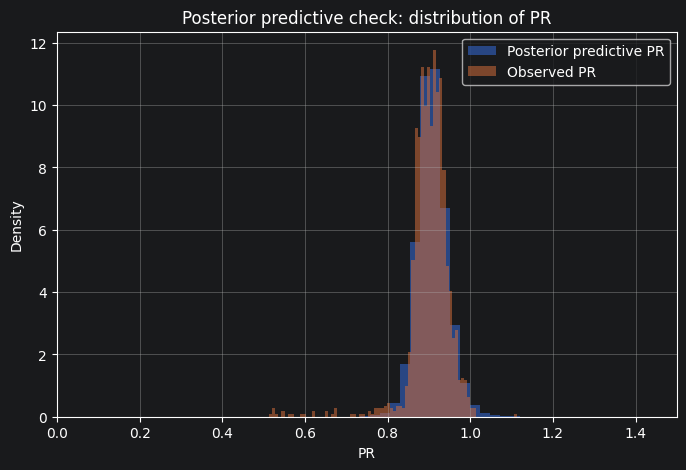

In [37]:
PR_pred = fit.stan_variable("PR_pred")
y_pred = fit.stan_variable("y_pred")

plt.figure(figsize=(8, 5))
plt.hist(PR_pred.flatten(), bins=100, density=True, alpha=0.55, label="Posterior predictive PR")
plt.hist(df["PR"], bins=80, density=True, alpha=0.55, label="Observed PR")
plt.xlim(0.3, 2.0)
plt.xlabel("PR")
plt.ylabel("Density")
plt.title("Posterior predictive check: distribution of PR")
plt.xlim([0, 1.5])
plt.legend()
plt.show()

## 9. Residual diagnostics — motivation for Model 2

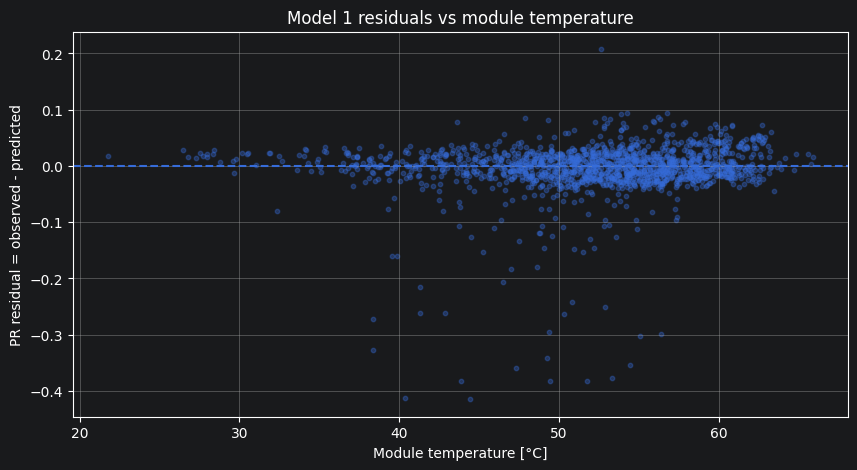

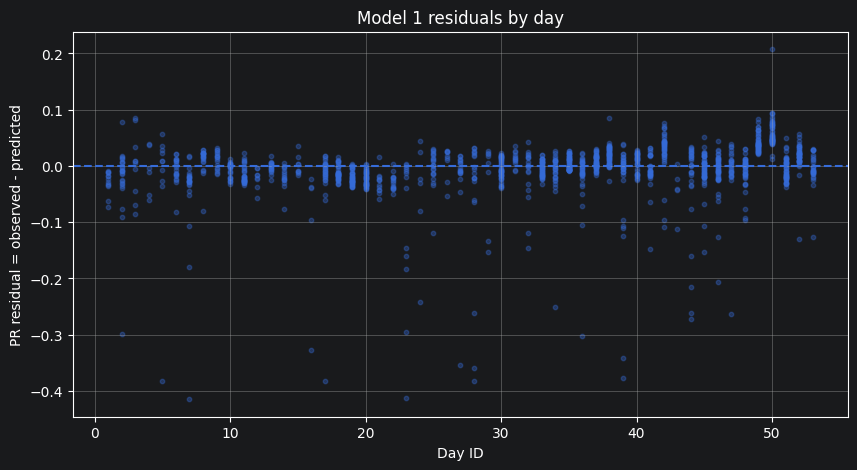

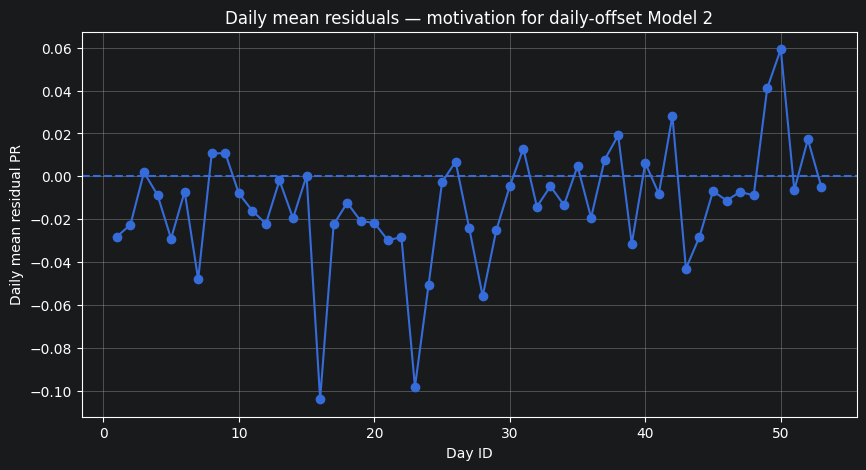

In [38]:
PR_mu_mean = np.exp(mu).mean(axis=0)

df_check = df.copy()
df_check["PR_pred_mean"] = PR_mu_mean
df_check["residual_PR"] = df_check["PR"] - df_check["PR_pred_mean"]

plt.figure(figsize=(10, 5))
plt.scatter(df_check["T_module_C"], df_check["residual_PR"], s=10, alpha=0.35)
plt.axhline(0, linestyle="--")
plt.xlabel("Module temperature [°C]")
plt.ylabel("PR residual = observed - predicted")
plt.title("Model 1 residuals vs module temperature")
plt.show()

if "day_id" in df_check.columns:
    plt.figure(figsize=(10, 5))
    plt.scatter(df_check["day_id"], df_check["residual_PR"], s=10, alpha=0.35)
    plt.axhline(0, linestyle="--")
    plt.xlabel("Day ID")
    plt.ylabel("PR residual = observed - predicted")
    plt.title("Model 1 residuals by day")
    plt.show()

    daily_res = df_check.groupby("day_id").agg(daily_mean_residual=("residual_PR", "mean")).reset_index()
    plt.figure(figsize=(10, 5))
    plt.plot(daily_res["day_id"], daily_res["daily_mean_residual"], "o-")
    plt.axhline(0, linestyle="--")
    plt.xlabel("Day ID")
    plt.ylabel("Daily mean residual PR")
    plt.title("Daily mean residuals — motivation for daily-offset Model 2")
    plt.show()
else:
    print("No day_id column found, skipping daily residual diagnostics.")

## 10. Save ArviZ object

In [39]:
idata1 = az.from_cmdstanpy(
    posterior=fit,
    posterior_predictive=["y_pred"],
    observed_data={"y": y},
    log_likelihood=["log_lik"],
)

with open("idata_model1_temperature_studentt.pkl", "wb") as f:
    pickle.dump(idata1, f)

print("Saved: idata_model1_temperature_studentt.pkl")

Saved: idata_model1_temperature_studentt.pkl


## Interpretation

Model 1 is a robust temperature-only baseline. Temperature is min-max normalized, so $x_T \in [0,1]$. In this scale, $\alpha$ is the expected $\log(PR)$ at the minimum observed module temperature and $\beta_T$ is the change in $\log(PR)$ between the minimum and maximum observed module temperature. The $+10^\circ C$ effect is included as a physical-scale summary. The Student-t likelihood makes the model less sensitive to remaining outliers. The model does not include wind or day-level effects.